In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
import kagglehub



In [2]:

path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Veri seti yolu:", path)


Veri seti yolu: /home/sero/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2


In [3]:
# GIRIS VE DOGRULAMA ICIN BOYUT AYARLAMALARI 
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import os

# Veri yolunu buraya yaz (kagglehub'dan gelen path)
data_dir = "/home/sero/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2"  # kendi path'ini yaz

# Transformlar
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

# Dataset yükleme
image_datasets = {
    'train': datasets.ImageFolder(os.path.join(data_dir, 'Training'), data_transforms['train']),
    'val':   datasets.ImageFolder(os.path.join(data_dir, 'Testing'),  data_transforms['val']),
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=2)
    for x in ['train', 'val']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names   = image_datasets['train'].classes
device        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {device}")
print(f"Sınıflar: {class_names}")
print(f"Eğitim: {dataset_sizes['train']} | Doğrulama: {dataset_sizes['val']}")

Device: cuda
Sınıflar: ['glioma', 'meningioma', 'notumor', 'pituitary']
Eğitim: 5600 | Doğrulama: 1600


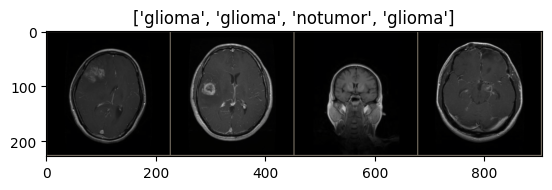

In [5]:
import torchvision
import numpy as np 
import matplotlib.pyplot as plt 
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.show()

inputs, classes = next(iter(dataloaders['train']))
out = torchvision.utils.make_grid(inputs[:4])
imshow(out, title=[class_names[x] for x in classes[:4]])

In [ ]:
RESNET MODEL OLUSTURMA 


In [7]:
def initialize_resnet(num_classes):
    model = models.resnext50_32x4d(weights='IMAGENET1K_V1')
    # ResNet'te son katman model.fc'dir
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, num_classes)
    return model.to(device)

# Hata almamak için class_names kontrolü
try:
    model = initialize_resnet(num_classes=len(class_names))
    print("ResNet50 modeli başarıyla yüklendi.")
except NameError:
    print("Hata: Lütfen önce veri setini yükleyen f3b03738 hücresini çalıştırın!")

ResNet50 modeli başarıyla yüklendi.


In [8]:
def train_model(model, criterion, optimizer, num_epochs=10):
    """
    ResNet modelini eğitmek için kullanılan temel döngü.
    Not: Daha kapsamlı olan sürüm 1cf00e31 hücresinde tanımlanmıştır.
    """
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

    return model

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Eğitim için kayıp fonksiyonu ve optimizer hazır.")

Eğitim için kayıp fonksiyonu ve optimizer hazır.


In [10]:
import time
import copy
import torch

def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val':
                scheduler.step(epoch_loss)
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
        print()

    time_elapsed = time.time() - since
    print(f'Eğitim tamamlandı: {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'En iyi doğrulama başarısı: {best_acc:4f}')
    model.load_state_dict(best_model_wts)
    return model

if 'scheduler' not in globals():
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

model_ft = train_model(model, criterion, optimizer, scheduler, num_epochs=10)

Epoch 1/10
----------
train Loss: 0.4158 Acc: 0.8561
val Loss: 0.5525 Acc: 0.8438

Epoch 2/10
----------
train Loss: 0.2047 Acc: 0.9282
val Loss: 0.5593 Acc: 0.9025

Epoch 3/10
----------
train Loss: 0.1583 Acc: 0.9480
val Loss: 0.6145 Acc: 0.8888

Epoch 4/10
----------
train Loss: 0.1407 Acc: 0.9545
val Loss: 0.6927 Acc: 0.8812

Epoch 5/10
----------
train Loss: 0.0583 Acc: 0.9809
val Loss: 0.4344 Acc: 0.9419

Epoch 6/10
----------
train Loss: 0.0338 Acc: 0.9909
val Loss: 0.4709 Acc: 0.9406

Epoch 7/10
----------
train Loss: 0.0315 Acc: 0.9895
val Loss: 0.4631 Acc: 0.9463

Epoch 8/10
----------
train Loss: 0.0239 Acc: 0.9929
val Loss: 0.4664 Acc: 0.9463

Epoch 9/10
----------
train Loss: 0.0157 Acc: 0.9955
val Loss: 0.4716 Acc: 0.9469

Epoch 10/10
----------
train Loss: 0.0188 Acc: 0.9948
val Loss: 0.4715 Acc: 0.9469

Eğitim tamamlandı: 13m 41s
En iyi doğrulama başarısı: 0.946875


Test Doğruluğu: %94.69

Sınıflandırma Raporu:
              precision    recall  f1-score   support

      glioma       0.99      0.81      0.89       400
  meningioma       0.92      0.98      0.95       400
     notumor       0.91      1.00      0.95       400
   pituitary       0.98      1.00      0.99       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



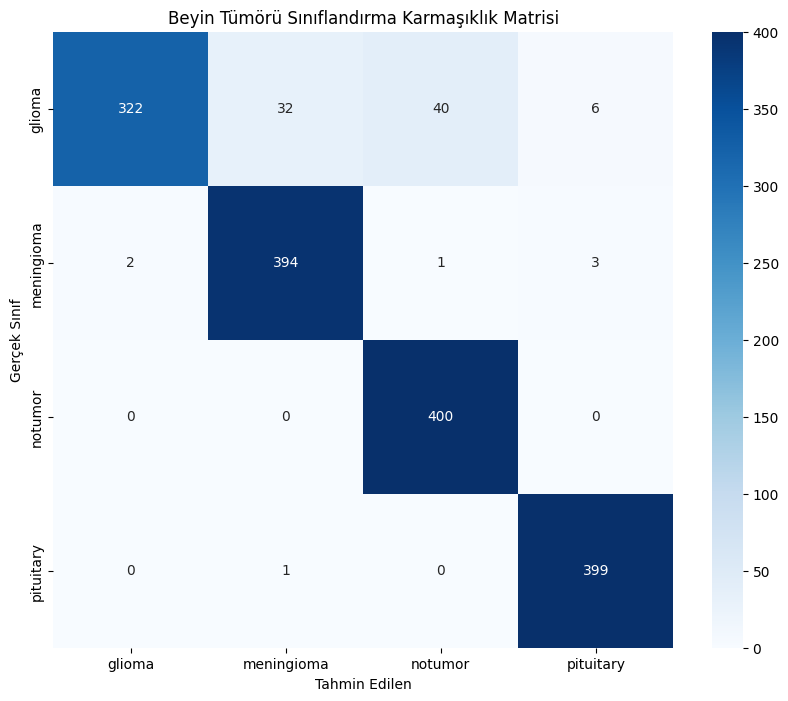

In [11]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import torch

def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print(f"Test Doğruluğu: %{accuracy_score(all_labels, all_preds)*100:.2f}")
    print("\nSınıflandırma Raporu:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Tahmin Edilen')
    plt.ylabel('Gerçek Sınıf')
    plt.title('Beyin Tümörü Sınıflandırma Karmaşıklık Matrisi')
    plt.show()

# En iyi sonuç veren model ile tekrar değerlendir
evaluate_model(model_ft, dataloaders['val'])

In [ ]:
from PIL import Image
import torch.nn.functional as F
import glob


def predict_image(model, class_names, image_path):
    # Görüntüyü aç
    img = Image.open(image_path).convert('RGB')
    plt.imshow(img)
    plt.title("Girdi Görüntüsü")
    plt.axis('off')
    plt.show()

    # Transform uygula
    img_t = data_transforms['val'](img)
    batch_t = torch.unsqueeze(img_t, 0).to(device)

    # Tahmin yap
    model.eval()
    with torch.no_grad():
        out = model(batch_t)
        probabilities = F.softmax(out, dim=1)
        conf, preds = torch.max(probabilities, 1)

    result = class_names[preds[0]]
    confidence = conf[0].item() * 100
    print(f"Tahmin: {result.upper()}")
    print(f"Güven Oranı: %{confidence:.2f}")
for path in glob.glob("/home/sero/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Training/meningioma/*.jpg"):
    print(f"\n--- {os.path.basename(path)} ---")
    predict_image(model_ft, class_names, path)

#predict_image(model_ft, class_names, "/home/sero/.cache/kagglehub/datasets/masoudnickparvar/brain-tumor-mri-dataset/versions/2/Testing/meningioma/Tr-aug-me_90.jpg")